# AIO2025 — Tutorial: Interpolate Temperature Data

Implementation of three interpolation methods for filling `NaN` values in temperature data:

1. **Nearest Neighbor Interpolation** — pick the value of the nearest non-NaN neighbor.
2. **Linear Interpolation** — fit a straight line between the two surrounding non-NaN points.
3. **Average Interpolation** — special case of linear interpolation: simple mean of the immediate neighbors.

Reference dataset (from the PDF, Figure 1):

| index | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|---|---|---|---|---|---|---|---|---|---|---|
| value | 17.15 | 17.80 | NaN | 18.88 | 18.91 | 15.39 | 15.55 | NaN | NaN | 11.55 |

## 0. Install dependencies with `uv`

In [ ]:
#!uv pip install pandas numpy matplotlib streamlit

Using Python 3.11.15 environment at: /home/vlilab/workspace/crawl4ai/.venv
Checked 4 packages in 6ms


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load CSV with missing values

In [3]:
df = pd.read_csv('temp_data_missing.csv', skip_blank_lines=False)
df

,temperature
0,9.5
1,9.4
2,9.4
3,8.3
4,8.8
5,9.2
6,7.8
7,NaN
8,10.8
9,13.8


In [4]:
data_list = df['temperature'].tolist()
print('Original data:')
print(data_list)
print(f'\nNumber of NaN values: {sum(pd.isna(v) for v in data_list)}')

Original data:
[9.5, 9.4, 9.4, 8.3, 8.8, 9.2, 7.8, nan, 10.8, 13.8, 16.1, 17.2, 17.8, nan, 18.9, 18.9, 15.5, 15.6, 14.3, nan, 11.6, 11.2, 10.2, 10.2]

Number of NaN values: 3


## 2. Nearest Neighbor Interpolation

For each NaN, find the closest non-NaN value to the left and to the right. Pick whichever is **closer by index distance**. Tie-breaker (equal distance): prefer the left value (smaller index).

In [5]:
def nearest_interpolation(data_list):
    """Nearest-neighbor interpolation for a list with NaN values."""
    interpolated_list = data_list[:]

    for i in range(len(interpolated_list)):
        if pd.isna(interpolated_list[i]):
            left_index, right_index = None, None
            left_distance = right_distance = float('inf')
            left_value = right_value = None

            # Search left for nearest non-NaN
            for j in range(i - 1, -1, -1):
                if not pd.isna(interpolated_list[j]):
                    left_index = j
                    left_value = interpolated_list[j]
                    left_distance = i - j
                    break

            # Search right for nearest non-NaN
            for j in range(i + 1, len(interpolated_list)):
                if not pd.isna(interpolated_list[j]):
                    right_index = j
                    right_value = interpolated_list[j]
                    right_distance = j - i
                    break

            # Tie -> left wins (<=)
            if left_distance <= right_distance:
                interpolated_list[i] = left_value
            else:
                interpolated_list[i] = right_value

    return interpolated_list


nn_result = nearest_interpolation(data_list)
print('Nearest Neighbor result:')
for i, v in enumerate(nn_result):
    print(f'  index {i}: {v}')

Nearest Neighbor result:
  index 0: 9.5
  index 1: 9.4
  index 2: 9.4
  index 3: 8.3
  index 4: 8.8
  index 5: 9.2
  index 6: 7.8
  index 7: 7.8
  index 8: 10.8
  index 9: 13.8
  index 10: 16.1
  index 11: 17.2
  index 12: 17.8
  index 13: 17.8
  index 14: 18.9
  index 15: 18.9
  index 16: 15.5
  index 17: 15.6
  index 18: 14.3
  index 19: 14.3
  index 20: 11.6
  index 21: 11.2
  index 22: 10.2
  index 23: 10.2


Expected from the PDF:
- index 2 -> 17.80 (tie between index 1 and 3, left wins)
- index 7 -> NaN's nearest non-NaN is index 6 (15.55) at distance 1; right side nearest is index 9 (11.55) at distance 2 -> picks **15.55**
- index 8 -> right neighbor index 9 is at distance 1, left non-NaN index 6 is at distance 2 -> picks **11.55**

## 3. Linear Interpolation

For each NaN at position `x`, find the two surrounding non-NaN points `(x1, y1)` (left) and `(x2, y2)` (right), then apply:

$$y = y_1 + (y_2 - y_1) \cdot \frac{x - x_1}{x_2 - x_1}$$

Note: the function uses already-interpolated values for subsequent NaNs (sequential filling).

In [6]:
def linear_interpolation(data_list):
    """Linear interpolation for a list with NaN values."""
    interpolated_list = data_list[:]
    nan_indices = [i for i, x in enumerate(interpolated_list) if pd.isna(x)]

    for i in nan_indices:
        # Nearest non-NaN on the left (may have been filled earlier)
        prev_index, prev_val = -1, None
        for j in range(i - 1, -1, -1):
            if not pd.isna(interpolated_list[j]):
                prev_index, prev_val = j, interpolated_list[j]
                break

        # Nearest non-NaN on the right
        next_index, next_val = -1, None
        for j in range(i + 1, len(interpolated_list)):
            if not pd.isna(interpolated_list[j]):
                next_index, next_val = j, interpolated_list[j]
                break

        if prev_index != -1 and next_index != -1:
            x1, y1 = prev_index, prev_val
            x2, y2 = next_index, next_val
            x = i
            interpolated_list[i] = y1 + (y2 - y1) * (x - x1) / (x2 - x1)
        elif prev_index != -1:
            interpolated_list[i] = prev_val
        elif next_index != -1:
            interpolated_list[i] = next_val

    return interpolated_list


lin_result = linear_interpolation(data_list)
print('Linear Interpolation result:')
for i, v in enumerate(lin_result):
    print(f'  index {i}: {v:.4f}' if not pd.isna(v) else f'  index {i}: NaN')

Linear Interpolation result:
  index 0: 9.5000
  index 1: 9.4000
  index 2: 9.4000
  index 3: 8.3000
  index 4: 8.8000
  index 5: 9.2000
  index 6: 7.8000
  index 7: 9.3000
  index 8: 10.8000
  index 9: 13.8000
  index 10: 16.1000
  index 11: 17.2000
  index 12: 17.8000
  index 13: 18.3500
  index 14: 18.9000
  index 15: 18.9000
  index 16: 15.5000
  index 17: 15.6000
  index 18: 14.3000
  index 19: 12.9500
  index 20: 11.6000
  index 21: 11.2000
  index 22: 10.2000
  index 23: 10.2000


Expected from the PDF:
- index 2: $17.80 + (18.88 - 17.80) \cdot \frac{2-1}{3-1} = 18.34$
- index 7: $15.55 + (11.55 - 15.55) \cdot \frac{7-6}{9-6} \approx 14.2167$
- index 8: depends on whether index 7 was already filled (sequential filling). Using filled value at 7: between indices 7 and 9.

## 4. Average Interpolation

Special case of Linear Interpolation when the missing point sits exactly between its two known neighbors:

$$y = \frac{y_0 + y_1}{2}$$

This implementation only checks the **immediate** neighbors `i-1` and `i+1`. When one of them is NaN, falls back to whichever side is valid.

In [7]:
def average_interpolation(data_list):
    """Average interpolation: mean of the immediate left/right neighbors."""
    interpolated_list = data_list[:]
    nan_indices = [i for i, x in enumerate(interpolated_list) if pd.isna(x)]

    for i in nan_indices:
        prev_val, next_val = None, None

        if i > 0 and not pd.isna(interpolated_list[i - 1]):
            prev_val = interpolated_list[i - 1]

        if i < len(interpolated_list) - 1 and not pd.isna(interpolated_list[i + 1]):
            next_val = interpolated_list[i + 1]

        if prev_val is not None and next_val is not None:
            interpolated_list[i] = (prev_val + next_val) / 2
        elif prev_val is not None:
            interpolated_list[i] = prev_val
        elif next_val is not None:
            interpolated_list[i] = next_val

    return interpolated_list


avg_result = average_interpolation(data_list)
print('Average Interpolation result:')
for i, v in enumerate(avg_result):
    print(f'  index {i}: {v:.4f}' if not pd.isna(v) else f'  index {i}: NaN')

Average Interpolation result:
  index 0: 9.5000
  index 1: 9.4000
  index 2: 9.4000
  index 3: 8.3000
  index 4: 8.8000
  index 5: 9.2000
  index 6: 7.8000
  index 7: 9.3000
  index 8: 10.8000
  index 9: 13.8000
  index 10: 16.1000
  index 11: 17.2000
  index 12: 17.8000
  index 13: 18.3500
  index 14: 18.9000
  index 15: 18.9000
  index 16: 15.5000
  index 17: 15.6000
  index 18: 14.3000
  index 19: 12.9500
  index 20: 11.6000
  index 21: 11.2000
  index 22: 10.2000
  index 23: 10.2000


Expected from the PDF:
- index 2: $(17.80 + 18.88)/2 = 18.34$ — same as Linear (centered between two known points).
- index 7: both neighbors NaN at first pass; depending on iteration order in the implementation. With this naive version, index 7 sees `i-1=6` (15.55) and `i+1=8` (NaN) -> falls back to 15.55.
- index 8: sees `i-1=7` (just filled to 15.55) and `i+1=9` (11.55) -> averages to 13.55.

## 5. Side-by-side comparison

In [8]:
comparison = pd.DataFrame({
    'index': range(len(data_list)),
    'original': data_list,
    'nearest': nn_result,
    'linear': lin_result,
    'average': avg_result,
})
comparison

,index,original,nearest,linear,average
0,0,9.5,9.5,9.50,9.50
1,1,9.4,9.4,9.40,9.40
2,2,9.4,9.4,9.40,9.40
3,3,8.3,8.3,8.30,8.30
4,4,8.8,8.8,8.80,8.80
5,5,9.2,9.2,9.20,9.20
6,6,7.8,7.8,7.80,7.80
7,7,NaN,7.8,9.30,9.30
8,8,10.8,10.8,10.80,10.80
9,9,13.8,13.8,13.80,13.80


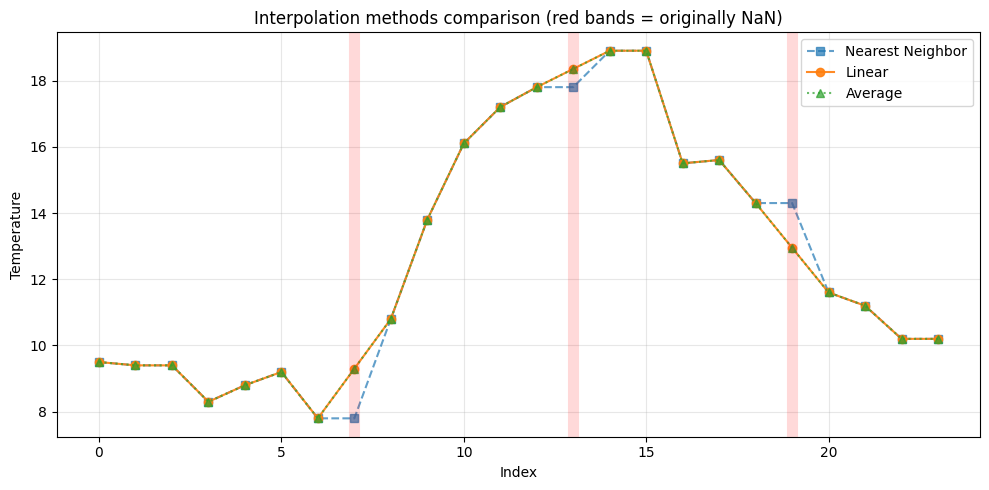

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
x = list(range(len(data_list)))

ax.plot(x, nn_result,  marker='s', linestyle='--', label='Nearest Neighbor', alpha=0.7)
ax.plot(x, lin_result, marker='o', linestyle='-',  label='Linear',  alpha=0.9)
ax.plot(x, avg_result, marker='^', linestyle=':',  label='Average', alpha=0.7)

# Highlight the originally missing positions
missing_idx = [i for i, v in enumerate(data_list) if pd.isna(v)]
for mi in missing_idx:
    ax.axvline(mi, color='red', alpha=0.15, linewidth=8)

ax.set_xlabel('Index')
ax.set_ylabel('Temperature')
ax.set_title('Interpolation methods comparison (red bands = originally NaN)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Streamlit demo (optional)

Section II.4 of the PDF mentions a Streamlit app. Run it from the terminal:

```bash
uv pip install streamlit
streamlit run streamlit_app.py
```

Then upload `temp_data_missing.csv` in the browser UI.